In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "sci.med"
]

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers","footers","quotes")
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers","footers","quotes")
)

In [3]:
categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "sci.med"
]

In [4]:
print(train_data.data[0])

The O's just lost to the Rangers a few minutes ago I was not too happy about
the pitching of Rick Sutcliffe (6 runs in 6 innings, 5 in the 3?) This puts
me in remembering the 1990 O's season. After '89 we didn't do much over
winter and we wound up in 5th. Now I know that Mussina, McDonald, and Rhodes
are better pitching prospects than Ballard and Milacki but are any other
Oriole fans scared out there?

Admiral Steve C. Liu


In [5]:
print(
    train_data.
      target_names[
          train_data.target[0]
      ]
    )

rec.sport.baseball


In [6]:
train_counts = pd.Series(
    train_data.target
).value_counts().sort_index()

category_names = train_data.target_names

count_df = pd.DataFrame({
    "Category": category_names,
    "Documents": train_counts.values
})

print(count_df)

             Category  Documents
0       comp.graphics        584
1  rec.sport.baseball        597
2             sci.med        594
3           sci.space        593


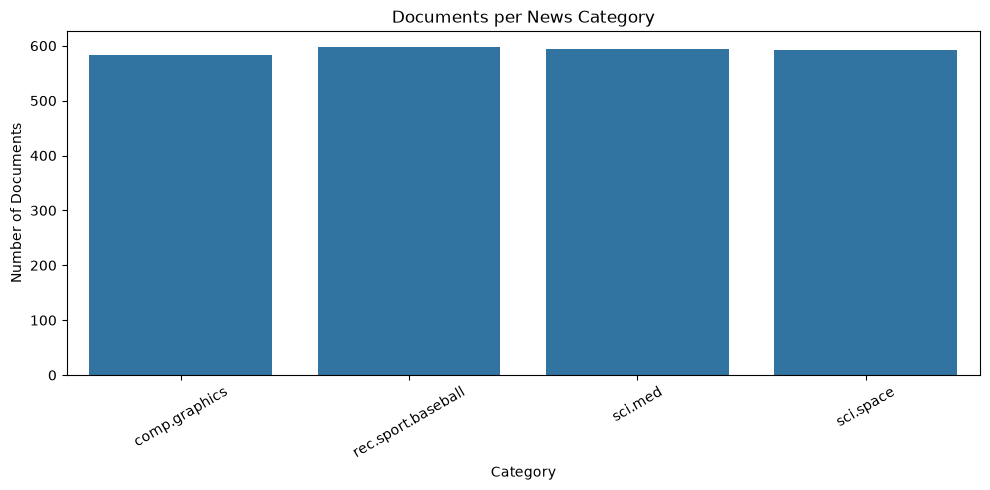

In [7]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=count_df,
    x="Category",
    y="Documents"
)

plt.title("Documents per News Category")
plt.xlabel("Category")
plt.ylabel("Number of Documents")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [8]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=10000
)

In [9]:
x_train = vectorizer.fit_transform(
    train_data.data
)

x_test = vectorizer.transform(
    test_data.data
)

In [10]:
print("Training shape : ",x_train.shape)
print("Testing shape : ",x_test.shape)

Training shape :  (2368, 10000)
Testing shape :  (1576, 10000)


In [11]:
words = vectorizer.get_feature_names_out()
print(words[:50])

['00' '000' '0000' '00000' '00am' '00pm' '01' '02' '03' '04' '040' '05'
 '06' '067' '07' '08' '083' '09' '091' '10' '100' '1000' '101' '102'
 '1024' '1024x768' '103' '104' '105' '106' '107' '108' '109' '10th' '11'
 '110' '111' '1111' '112' '113' '114' '115' '117' '118' '119' '11th' '12'
 '120' '1200' '121']


In [12]:
model = MultinomialNB()
model.fit(
    x_train,
    train_data.target
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](4,)","[584.,597.,594.,593.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](4,)","[-1.4 ,-1.38,-1.38,-1.38]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](4,)","[0,1,2,3]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](4, 10000)","[[ 26., 12., 0.,..., 4., 5., 0.], [175., 66., 0.,..., 0., 0., 4.], [ 22., 31., 1.,..., 0., 0., 0.], [ 32., 92., 2.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](4, 10000)","[[ -7.66, -8.39,-10.96,..., -9.35, -9.17,-10.96], [ -5.52, -6.49,-10.69,...,-10.69,-10.69, -9.08], [ -7.93, -7.6 ,-10.37,...,-11.07,-11.07,-11.07], [ -7.66, -6.62,-10.05,...,-11.15,-11.15,-11.15]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [13]:
y_pred = model.predict(x_test)
print(y_pred[:20])

[3 3 1 1 1 3 0 1 2 3 1 1 3 2 2 2 2 3 1 2]


In [14]:
for prediction in y_pred[:10]:
    print(train_data.target_names[prediction])

sci.space
sci.space
rec.sport.baseball
rec.sport.baseball
rec.sport.baseball
sci.space
comp.graphics
rec.sport.baseball
sci.med
sci.space


In [15]:
accuracy = accuracy_score(
    test_data.target,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8857868020304569


In [16]:
print(
    classification_report(
        test_data.target,y_pred,
        target_names=train_data.target_names
    )
)

                    precision    recall  f1-score   support

     comp.graphics       0.90      0.89      0.90       389
rec.sport.baseball       0.84      0.93      0.88       397
           sci.med       0.88      0.89      0.88       396
         sci.space       0.94      0.83      0.88       394

          accuracy                           0.89      1576
         macro avg       0.89      0.89      0.89      1576
      weighted avg       0.89      0.89      0.89      1576



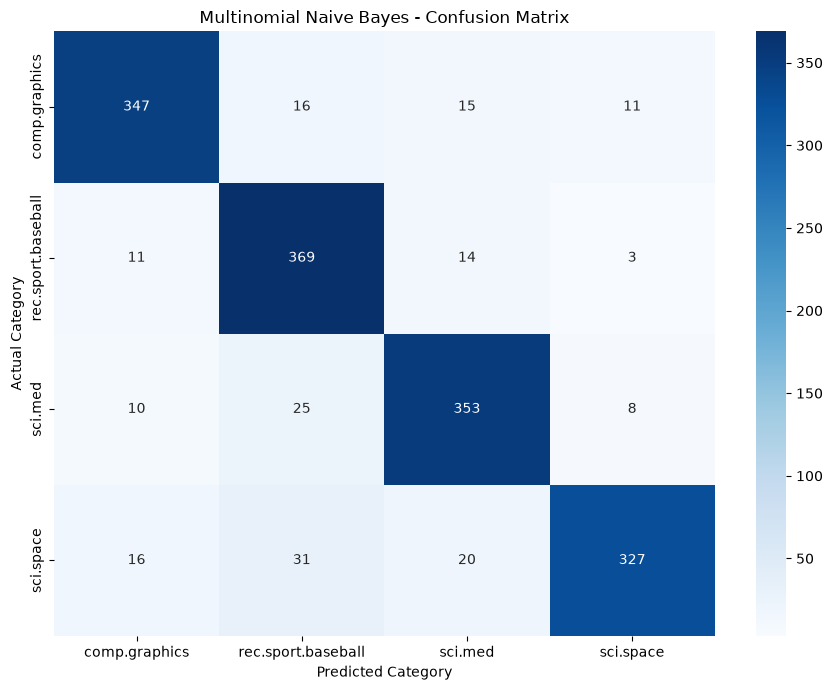

In [17]:
cm = confusion_matrix(
    test_data.target,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.target_names,
    yticklabels=train_data.target_names
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.title(
    "Multinomial Naive Bayes - Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [19]:
word_counts = np.asarray(
    x_train.sum(axis=0)
).flatten()

word_frequency = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "frequency": word_counts
})

word_frequency = word_frequency.sort_values(
    "frequency",
    ascending=False
)

print(
    word_frequency.head(20)
)

           word  frequency
8444      space       1060
3318        edu        835
5410       like        743
3144        don        722
5133       just        642
9077       time        623
9492        use        606
5215       know        594
9020      think        560
4145       good        548
9961       year        546
4657      image        530
6214        new        488
2711       data        487
6708     people        476
3129       does        450
7152    program        435
6133       nasa        429
4184   graphics        420
1332  available        404


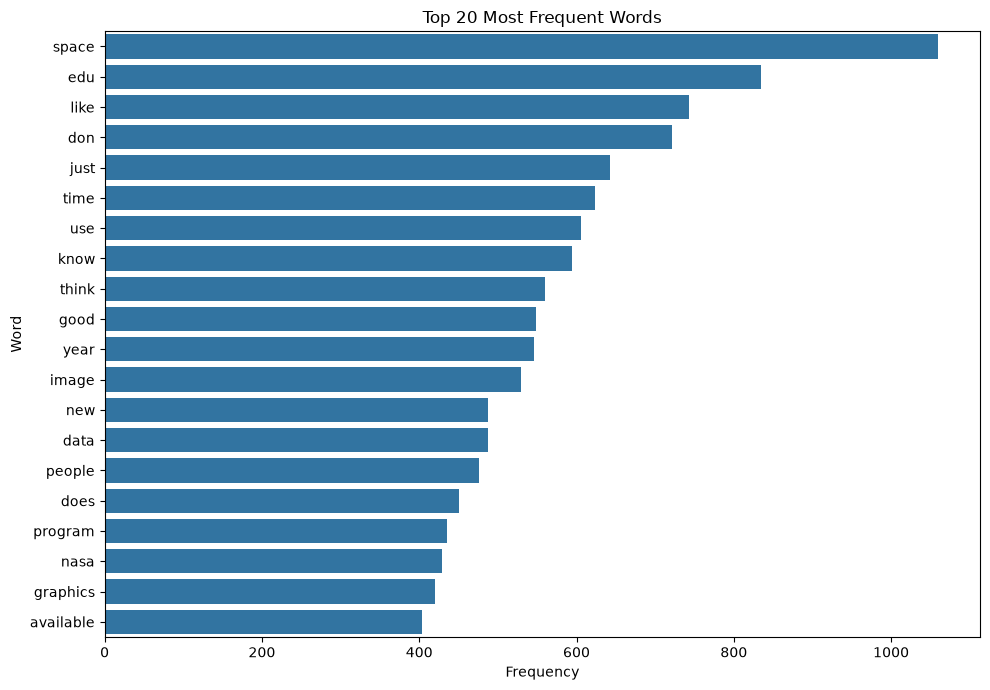

In [20]:
top_words = word_frequency.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [22]:
feature_names = vectorizer.get_feature_names_out()

for class_id, class_name in enumerate(
    train_data.target_names
):

    class_rows = (
        train_data.target == class_id
    )

    class_matrix = x_train[class_rows]

    counts = np.asarray(
        class_matrix.sum(axis=0)
    ).flatten()

    top_indices = counts.argsort()[-10:][::-1]

    print("\nCategory:", class_name)

    for index in top_indices:
        print(
            feature_names[index],
            counts[index]
        )


Category: comp.graphics
image 484
graphics 410
edu 297
jpeg 267
file 265
use 225
data 219
files 217
images 212
software 212

Category: rec.sport.baseball
year 310
game 204
good 200
team 195
think 189
don 186
00 175
just 161
like 153
games 149

Category: sci.med
edu 354
don 230
people 221
health 217
use 216
medical 206
like 201
know 191
com 190
time 180

Category: sci.space
space 989
nasa 374
launch 267
like 222
earth 222
data 216
orbit 201
time 197
shuttle 192
just 189


['nasa', 'space', 'orbit', 'baseball', 'game', 'player', 'medical', 'doctor', 'disease', 'graphics', 'computer', 'image']


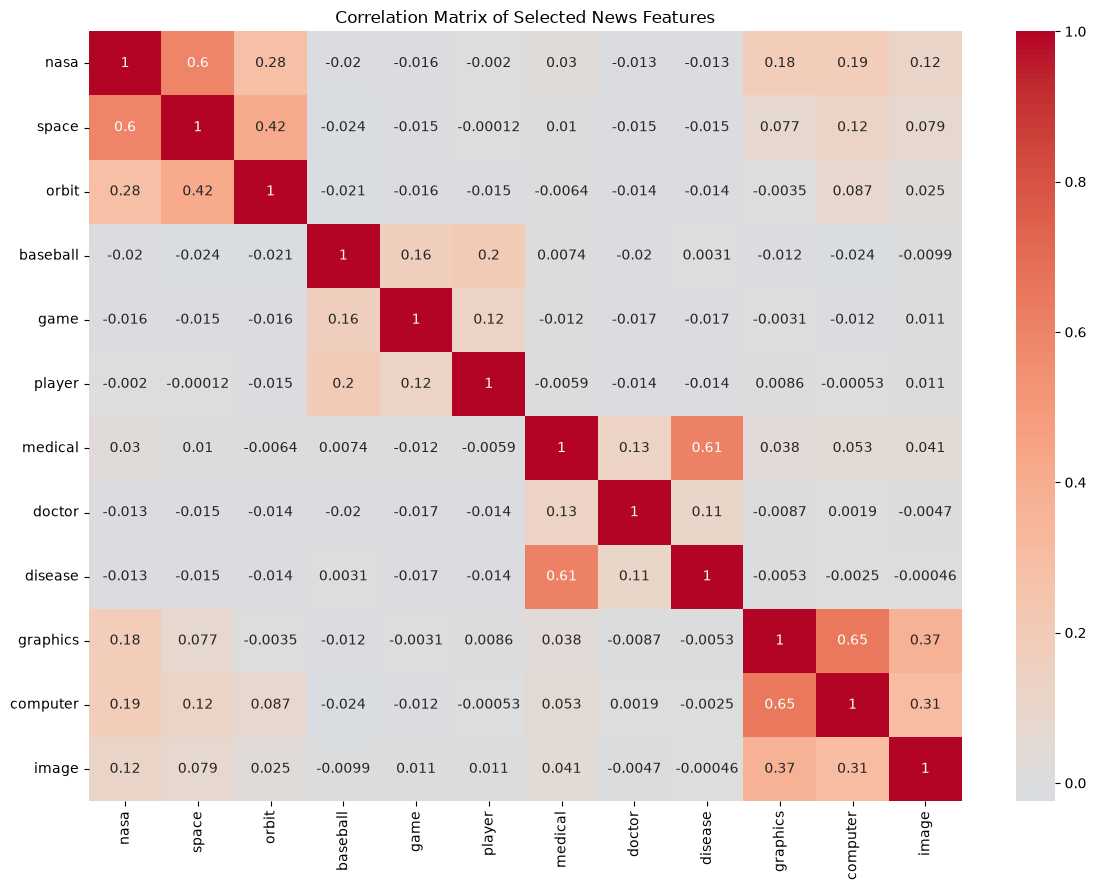

In [23]:
selected_words = [
    "nasa",
    "space",
    "orbit",
    "baseball",
    "game",
    "player",
    "medical",
    "doctor",
    "disease",
    "graphics",
    "computer",
    "image"
]

available_words = [
    word
    for word in selected_words
    if word in vectorizer.vocabulary_
]

print(available_words)

word_matrix = pd.DataFrame(
    x_train.toarray(),
    columns=feature_names
)

correlation_matrix = (
    word_matrix[available_words]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Selected News Features"
)

plt.tight_layout()

plt.show()

Predict Completely New News

In [24]:
new_articles = [

    """
    NASA successfully launched a spacecraft
    into orbit around the Earth. Scientists
    are studying the new space mission.
    """,

    """
    The baseball team won the game after
    scoring five runs in the final inning.
    The player hit a home run.
    """,

    """
    The patient was diagnosed with a serious
    medical condition and the doctor recommended
    a new treatment.
    """,

    """
    The computer graphics program can create
    high resolution images and 3D models.
    """
]

In [25]:
new_vectors = vectorizer.transform(
    new_articles
)
predictions = model.predict(
    new_vectors
)

In [26]:
for article, prediction in zip(
    new_articles,
    predictions
):

    category = train_data.target_names[
        prediction
    ]

    print("=" * 60)

    print("ARTICLE:")
    print(article.strip())

    print("\nPREDICTED CATEGORY:")
    print(category)

ARTICLE:
NASA successfully launched a spacecraft
    into orbit around the Earth. Scientists
    are studying the new space mission.

PREDICTED CATEGORY:
sci.space
ARTICLE:
The baseball team won the game after
    scoring five runs in the final inning.
    The player hit a home run.

PREDICTED CATEGORY:
rec.sport.baseball
ARTICLE:
The patient was diagnosed with a serious
    medical condition and the doctor recommended
    a new treatment.

PREDICTED CATEGORY:
sci.med
ARTICLE:
The computer graphics program can create
    high resolution images and 3D models.

PREDICTED CATEGORY:
comp.graphics


In [27]:
probabilities = model.predict_proba(
    new_vectors
)

for i, article in enumerate(new_articles):

    print("\n")
    print(article.strip())

    for class_name, probability in zip(
        train_data.target_names,
        probabilities[i]
    ):

        print(
            f"{class_name}: {probability:.4f}"
        )



NASA successfully launched a spacecraft
    into orbit around the Earth. Scientists
    are studying the new space mission.
comp.graphics: 0.0000
rec.sport.baseball: 0.0000
sci.med: 0.0000
sci.space: 1.0000


The baseball team won the game after
    scoring five runs in the final inning.
    The player hit a home run.
comp.graphics: 0.0000
rec.sport.baseball: 1.0000
sci.med: 0.0000
sci.space: 0.0000


The patient was diagnosed with a serious
    medical condition and the doctor recommended
    a new treatment.
comp.graphics: 0.0000
rec.sport.baseball: 0.0000
sci.med: 1.0000
sci.space: 0.0000


The computer graphics program can create
    high resolution images and 3D models.
comp.graphics: 1.0000
rec.sport.baseball: 0.0000
sci.med: 0.0000
sci.space: 0.0000


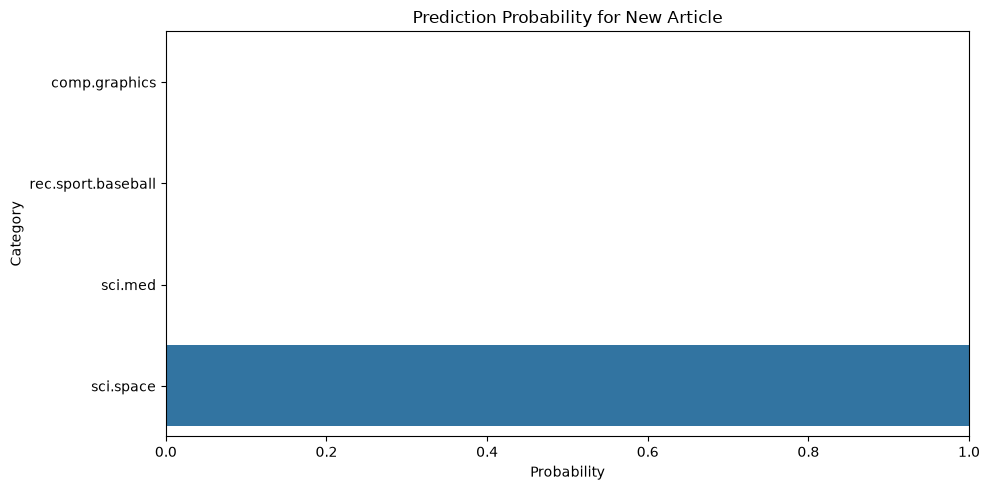

In [28]:
article_index = 0

probability_df = pd.DataFrame({
    "Category": train_data.target_names,
    "Probability": probabilities[article_index]
})

plt.figure(figsize=(10, 5))

sns.barplot(
    data=probability_df,
    x="Probability",
    y="Category"
)

plt.title(
    "Prediction Probability for New Article"
)

plt.xlabel("Probability")
plt.ylabel("Category")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()